<a href="https://colab.research.google.com/github/nagolkarrahul88-boop/CSL701-CE31_Machine-Learning-Lab/blob/main/Rahul_ML_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name: Rahul Vishram Nagolkar**
**Roll No:CE31**
**Batch: CE02**

# Machine Learning Experiment Number 3

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [70]:
uploaded = files.upload()
df = pd.read_csv("cardekho_dataset.csv")
display(df.head())



Saving cardekho_dataset.csv to cardekho_dataset (3).csv


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [71]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
categorical_attributes = df.select_dtypes(include="object").columns.tolist()

print("\nCategorical attributes:")
print(categorical_attributes)

X = df.drop("selling_price", axis=1)
y = df["selling_price"]

print("Input features:", X.columns.tolist())
print("Target variable:", y.name)



Number of rows: 15411
Number of columns: 14

Categorical attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']
Input features: ['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats']
Target variable: selling_price


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [72]:
print("Missing values in each column:")
print(df.isnull().sum())

df = df.dropna()

print("\nMissing values after preprocessing:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("Final dataset shape:", df.shape)

print("\nPreprocessing Method: Missing values were checked using isnull().sum() and incomplete rows were removed using dropna().")


Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values: 0
Final dataset shape: (15411, 14)

Preprocessing Method: Missing values were checked using isnull().sum() and incomplete rows were removed using dropna().


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [73]:
# Task 4: Select and Prepare Features

# 1. Display all available attributes
print("Available Attributes:")
print(df.columns.tolist())


# 2. Display data types
print("\nAttribute Data Types:")
print(df.dtypes)


# 3. Separate target variable
y = df["selling_price"]


# 4. Remove target variable from input features
X = df.drop("selling_price", axis=1)


# 5. Remove unnecessary columns
# Unnamed: 0 is an index column
# car_name is removed because it is a high-cardinality name field
X = X.drop(["Unnamed: 0", "car_name"], axis=1)


# 6. Display categorical attributes
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("\nCategorical Attributes:")
print(categorical_columns)


# 7. Convert categorical attributes into numerical values
# One-hot encoding is used for categorical features
X = pd.get_dummies(X, columns=categorical_columns,
                   drop_first=True, dtype=int)


# 8. Convert all features and target variable to float
X = X.astype(float)
y = y.astype(float)


# 9. Display prepared predictor matrix
print("\nPrepared Predictor Matrix X:")
display(X.head())


# 10. Display target vector
print("\nTarget Vector y:")
display(y.head())


# 11. Display dimensions
print("\nNumber of observations:", X.shape[0])
print("Number of predictor features:", X.shape[1])
print("X shape:", X.shape)
print("y shape:", y.shape)


# 12. Display final features
print("\nFinal Features Selected for the Model:")

for i, feature in enumerate(X.columns, start=1):
    print(i, ":", feature)


# 13. Display target variable
print("\nTarget Variable: selling_price")

Available Attributes:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Attribute Data Types:
Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

Categorical Attributes:
['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Prepared Predictor Matrix X:


,vehicle_age,km_driven,mileage,engine,max_power,seats,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,...,model_i10,model_i20,model_redi-GO,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9.0,120000.0,19.70,796.0,46.30,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,5.0,20000.0,18.90,1197.0,82.00,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
2,11.0,60000.0,17.00,1197.0,80.00,5.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
3,9.0,37000.0,20.92,998.0,67.10,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
4,6.0,30000.0,22.77,1498.0,98.59,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0



Target Vector y:


,selling_price
0,120000.0
1,550000.0
2,215000.0
3,226000.0
4,570000.0



Number of observations: 15411
Number of predictor features: 163
X shape: (15411, 163)
y shape: (15411,)

Final Features Selected for the Model:
1 : vehicle_age
2 : km_driven
3 : mileage
4 : engine
5 : max_power
6 : seats
7 : brand_BMW
8 : brand_Bentley
9 : brand_Datsun
10 : brand_Ferrari
11 : brand_Force
12 : brand_Ford
13 : brand_Honda
14 : brand_Hyundai
15 : brand_ISUZU
16 : brand_Isuzu
17 : brand_Jaguar
18 : brand_Jeep
19 : brand_Kia
20 : brand_Land Rover
21 : brand_Lexus
22 : brand_MG
23 : brand_Mahindra
24 : brand_Maruti
25 : brand_Maserati
26 : brand_Mercedes-AMG
27 : brand_Mercedes-Benz
28 : brand_Mini
29 : brand_Nissan
30 : brand_Porsche
31 : brand_Renault
32 : brand_Rolls-Royce
33 : brand_Skoda
34 : brand_Tata
35 : brand_Toyota
36 : brand_Volkswagen
37 : brand_Volvo
38 : model_5
39 : model_6
40 : model_7
41 : model_A4
42 : model_A6
43 : model_A8
44 : model_Alto
45 : model_Altroz
46 : model_Alturas
47 : model_Amaze
48 : model_Aspire
49 : model_Aura
50 : model_Baleno
51 : model

## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [82]:
# Task 5: Encode Categorical Variables

# Identify all categorical variables
categorical_variables = [
    "brand",
    "model",
    "seller_type",
    "fuel_type",
    "transmission_type"
]

print("Categorical Variables:")
print(categorical_variables)


# Create X from original dataset
X = df.drop("selling_price", axis=1)


# Remove unnecessary columns
X = X.drop(["Unnamed: 0", "car_name"], axis=1)


# Convert categorical variables into dummy variables
X = pd.get_dummies(
    X,
    columns=categorical_variables,
    drop_first=True,
    dtype=float
)


# Convert all predictors to float
X = X.astype(float)


# Target variable
y = df["selling_price"].astype(float)


# Display transformed dataset
print("\nTransformed Dataset:")
display(X.head())


# Verify data types
print("\nData Types After Encoding:")
print(X.dtypes)


# Verify all predictors are numerical
print("\nAre all predictors numerical?")

if all(np.issubdtype(dtype, np.number) for dtype in X.dtypes):
    print("Yes, all predictors are numerical.")
else:
    print("No, some predictors are still categorical.")


print("\nX Shape:", X.shape)

Categorical Variables:
['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Transformed Dataset:


,vehicle_age,km_driven,mileage,engine,max_power,seats,Car_Age,brand_BMW,brand_Bentley,brand_Datsun,...,model_i10,model_i20,model_redi-GO,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9.0,120000.0,19.70,796.0,46.30,5.0,9.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,5.0,20000.0,18.90,1197.0,82.00,5.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
2,11.0,60000.0,17.00,1197.0,80.00,5.0,11.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
3,9.0,37000.0,20.92,998.0,67.10,5.0,9.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
4,6.0,30000.0,22.77,1498.0,98.59,5.0,6.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0



Data Types After Encoding:
vehicle_age                 float64
km_driven                   float64
mileage                     float64
engine                      float64
max_power                   float64
                             ...   
fuel_type_Diesel            float64
fuel_type_Electric          float64
fuel_type_LPG               float64
fuel_type_Petrol            float64
transmission_type_Manual    float64
Length: 164, dtype: object

Are all predictors numerical?
Yes, all predictors are numerical.

X Shape: (15411, 164)


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [83]:
# Task 6: Perform Feature Engineering

# Create Car_Age using the existing vehicle_age column
df["Car_Age"] = df["vehicle_age"]

# Display several values
print("Car Age values:")
display(df[["vehicle_age", "Car_Age"]].head(10))

# Verify that the ages are reasonable
print("\nCar Age Statistics:")
print(df["Car_Age"].describe())

print("\nMinimum Car Age:", df["Car_Age"].min())
print("Maximum Car Age:", df["Car_Age"].max())

# Decision about the original Year feature
print("\nDecision:")
print("The original Year feature is not retained because the dataset")
print("does not contain a Year column. The existing vehicle_age column")
print("already provides the age of each car.")

Car Age values:


,vehicle_age,Car_Age
0,9,9
1,5,5
2,11,11
3,9,9
4,6,6
5,8,8
6,8,8
7,3,3
8,2,2
9,4,4



Car Age Statistics:
count    15411.000000
mean         6.036338
std          3.013291
min          0.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         29.000000
Name: Car_Age, dtype: float64

Minimum Car Age: 0
Maximum Car Age: 29

Decision:
The original Year feature is not retained because the dataset
does not contain a Year column. The existing vehicle_age column
already provides the age of each car.


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

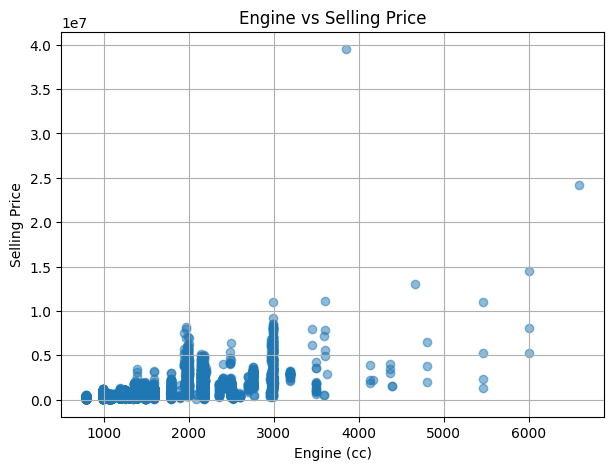

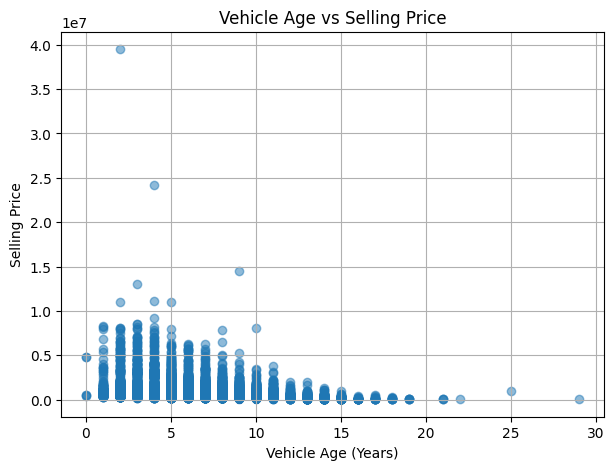

In [84]:
# Task 7: Exploratory Data Analysis

# Convert required columns to numeric
df["engine"] = pd.to_numeric(df["engine"], errors="coerce")
df["selling_price"] = pd.to_numeric(df["selling_price"], errors="coerce")
df["vehicle_age"] = pd.to_numeric(df["vehicle_age"], errors="coerce")

# Remove rows with missing values in required columns
plot_df = df.dropna(
    subset=["engine", "selling_price", "vehicle_age"]
)


# Scatter Plot 1: Engine vs Selling Price
plt.figure(figsize=(7, 5))

plt.scatter(
    plot_df["engine"],
    plot_df["selling_price"],
    alpha=0.5
)

plt.xlabel("Engine (cc)")
plt.ylabel("Selling Price")
plt.title("Engine vs Selling Price")
plt.grid(True)
plt.show()


# Scatter Plot 2: Vehicle Age vs Selling Price
plt.figure(figsize=(7, 5))

plt.scatter(
    plot_df["vehicle_age"],
    plot_df["selling_price"],
    alpha=0.5
)

plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Selling Price")
plt.title("Vehicle Age vs Selling Price")
plt.grid(True)
plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [86]:
# Task 8: Standardize Numerical Features

numerical_features = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

print("Numerical Features:")
print(numerical_features)


# Get positions of numerical features
feature_names = X.columns.tolist()

numerical_indices = [
    feature_names.index(feature)
    for feature in numerical_features
]


# Convert to NumPy arrays
X_train = X_train.to_numpy(dtype=float)
X_test = X_test.to_numpy(dtype=float)

y_train = y_train.to_numpy(dtype=float)
y_test = y_test.to_numpy(dtype=float)


# Mean and standard deviation from TRAINING data only
train_mean = np.mean(
    X_train[:, numerical_indices],
    axis=0
)

train_std = np.std(
    X_train[:, numerical_indices],
    axis=0
)

# Avoid division by zero
train_std[train_std == 0] = 1


# Standardize training data
X_train[:, numerical_indices] = (
    X_train[:, numerical_indices] - train_mean
) / train_std


# Standardize test data using training statistics
X_test[:, numerical_indices] = (
    X_test[:, numerical_indices] - train_mean
) / train_std


# Display results
print("\nTraining Mean:")
for feature, mean in zip(numerical_features, train_mean):
    print(feature, ":", round(mean, 4))


print("\nTraining Standard Deviation:")
for feature, std in zip(numerical_features, train_std):
    print(feature, ":", round(std, 4))


print("\nStandardized Training Features:")
display(pd.DataFrame(
    X_train[:, numerical_indices],
    columns=numerical_features
).head())


print("\nStandardized Test Features:")
display(pd.DataFrame(
    X_test[:, numerical_indices],
    columns=numerical_features
).head())


print("\nSelling_Price was not standardized.")

Numerical Features:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

Training Mean:
vehicle_age : 6.0324
km_driven : 55692.8196
mileage : 19.6916
engine : 1485.0374
max_power : 100.5167
seats : 5.3262

Training Standard Deviation:
vehicle_age : 3.0187
km_driven : 54470.9544
mileage : 4.1726
engine : 518.276
max_power : 42.744
seats : 0.8096

Standardized Training Features:


,vehicle_age,km_driven,mileage,engine,max_power,seats
0,1.976831,0.317732,0.160198,-0.555761,-0.505726,-0.402990
1,-0.673275,0.042356,1.844986,-0.457357,-0.620363,-0.402990
2,0.320515,0.739976,0.258457,-0.457357,-0.275051,2.067455
3,-1.667065,-0.939819,-0.309529,0.025011,0.440606,-0.402990
4,1.645568,0.115790,0.002025,-1.329480,-1.268407,-0.402990



Standardized Test Features:


,vehicle_age,km_driven,mileage,engine,max_power,seats
0,-1.004538,-0.563471,-2.322647,1.279169,1.625569,-0.402990
1,0.651778,0.409524,-0.752894,0.931864,1.099413,-0.402990
2,0.320515,0.124969,1.320137,-0.457357,-0.620363,-0.402990
3,-0.342012,-0.563471,1.348896,-0.553831,-0.550177,0.832232
4,-1.004538,-0.618547,-0.357461,-0.551902,-0.276454,-0.402990



Selling_Price was not standardized.


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [85]:
# Task 9: Split the Dataset

np.random.seed(42)

indices = np.arange(len(X))
np.random.shuffle(indices)

train_size = int(0.80 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

print("Total observations:", len(X))
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Total observations: 15411
Training observations: 12328
Testing observations: 3083

Training data shape: (12328, 164)
Testing data shape: (3083, 164)


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [89]:
# Task 10: Construct the Feature Matrix

# Convert training and testing features to NumPy arrays
Xtrain = np.asarray(X_train, dtype=float)
Xtest = np.asarray(X_test, dtype=float)

# Convert target variables to NumPy arrays
ytrain = np.asarray(y_train, dtype=float)
ytest = np.asarray(y_test, dtype=float)


# Display number of observations
print("Number of training observations:", Xtrain.shape[0])
print("Number of testing observations:", Xtest.shape[0])


# Display number of predictor columns
print("\nNumber of predictor columns:", Xtrain.shape[1])


# Display shapes
print("\nShape of Xtrain:", Xtrain.shape)
print("Shape of ytrain:", ytrain.shape)
print("Shape of Xtest:", Xtest.shape)
print("Shape of ytest:", ytest.shape)

Number of training observations: 12328
Number of testing observations: 3083

Number of predictor columns: 164

Shape of Xtrain: (12328, 164)
Shape of ytrain: (12328,)
Shape of Xtest: (3083, 164)
Shape of ytest: (3083,)


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [90]:
# Task 11: Add Bias / Intercept Term

# Add a column of 1s to the training feature matrix
Xtrain_bias = np.column_stack((
    np.ones(Xtrain.shape[0]),
    Xtrain
))

# Add a column of 1s to the testing feature matrix
Xtest_bias = np.column_stack((
    np.ones(Xtest.shape[0]),
    Xtest
))


# Display the new shapes
print("Original Xtrain shape:", Xtrain.shape)
print("Xtrain with bias shape:", Xtrain_bias.shape)

print("\nOriginal Xtest shape:", Xtest.shape)
print("Xtest with bias shape:", Xtest_bias.shape)


# Display first 5 rows
print("\nFirst 5 rows of Xtrain with bias:")
print(Xtrain_bias[:5])


print("\nFirst 5 rows of Xtest with bias:")
print(Xtest_bias[:5])


# Verify first column
print("\nFirst column of Xtrain:")
print(Xtrain_bias[:5, 0])

print("\nFirst column of Xtest:")
print(Xtest_bias[:5, 0])

Original Xtrain shape: (12328, 164)
Xtrain with bias shape: (12328, 165)

Original Xtest shape: (3083, 164)
Xtest with bias shape: (3083, 165)

First 5 rows of Xtrain with bias:
[[ 1.00000000e+00  1.97683120e+00  3.17732278e-01  1.60198190e-01
  -5.55760666e-01 -5.05726422e-01 -4.02990451e-01  1.20000000e+01
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e

## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [91]:
# Task 12: Implement Ordinary Least Squares (OLS)

def ols(X, y):

    # Calculate X^T X
    XTX = X.T @ X

    # Calculate X^T y
    XTy = X.T @ y

    # Calculate pseudo-inverse of X^T X
    XTX_pinv = np.linalg.pinv(XTX)

    # Calculate regression coefficients
    beta = XTX_pinv @ XTy

    return beta


# Apply OLS to training data
beta = ols(Xtrain_bias, ytrain)


# Display coefficients
print("Regression Coefficients:")
print(beta)


# Display intercept
print("\nIntercept (β0):", beta[0])


# Display number of coefficients
print("\nNumber of coefficients:", len(beta))

Regression Coefficients:
[ 6.79472735e+05 -1.24731927e+06 -2.68525926e+04 -9.99552614e+03
 -8.19116730e+04  2.49797532e+05 -3.27985196e+04  3.33541412e+05
 -1.29588706e+06  4.79105358e+06 -1.74426832e+06  1.69081143e+07
 -9.13699744e+05 -1.59576142e+06 -1.68652962e+06 -1.81497415e+06
  6.24201918e-07 -8.93768075e+05  1.38037642e+05 -5.94457978e+04
 -6.63163499e+05  2.20518260e+05  1.63352007e+06 -7.96132308e+05
 -1.62708114e+06 -2.00317921e+06  1.26188488e+06  4.52739620e+05
  1.98013595e+05 -4.10285816e+05 -1.34063806e+06  1.30707533e+06
 -1.65147768e+06 -7.06463201e-08 -1.44257309e+06 -1.83964982e+06
 -1.29465810e+06 -1.40815057e+06  1.04494837e+06  9.49451729e+05
  2.62524077e+06  1.70720689e+06 -1.42014246e+06 -1.07780759e+06
  1.82347976e+05 -9.15848716e+04 -4.35323650e+05  1.14270895e+06
 -5.37188104e+05 -6.67121793e+05 -2.69198495e+05 -1.37129954e+05
 -4.17334996e+04  4.52739620e+05 -1.53550892e+06 -1.97499862e+05
  4.54562275e+03  2.68840755e+05 -8.22494732e+04  3.22911427e+05


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [92]:
# Task 13: Check Matrix Singularity

# Calculate X^T X
XTX = Xtrain_bias.T @ Xtrain_bias

# Calculate determinant
det_XTX = np.linalg.det(XTX)

print("Determinant of X^T X:", det_XTX)


# Check whether the matrix is singular or nearly singular
if np.isclose(det_XTX, 0):
    print("\nX^T X is singular or nearly singular.")
    print("There may be redundant or highly correlated features.")
else:
    print("\nX^T X is not singular.")
    print("The matrix can be inverted normally.")


# Check matrix rank
rank = np.linalg.matrix_rank(XTX)

print("\nMatrix rank:", rank)
print("Matrix size:", XTX.shape[0])

if rank < XTX.shape[0]:
    print("Observation: X^T X does not have full rank.")
else:
    print("Observation: X^T X has full rank.")

Determinant of X^T X: 0.0

X^T X is singular or nearly singular.
There may be redundant or highly correlated features.

Matrix rank: 131
Matrix size: 165
Observation: X^T X does not have full rank.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [93]:
# Task 14: Train the Regression Model

# Apply OLS to the training data
beta = ols(Xtrain_bias, ytrain)

# Display intercept
print("Intercept (β0):", beta[0])

# Feature names including the bias term
feature_names_with_bias = ["Intercept"] + X.columns.tolist()

# Display coefficient for each feature
print("\nRegression Coefficients:")

for feature, coefficient in zip(feature_names_with_bias, beta):
    print(f"{feature}: {coefficient}")

Intercept (β0): 679472.734683896

Regression Coefficients:
Intercept: 679472.734683896
vehicle_age: -1247319.2701960825
km_driven: -26852.59260925919
mileage: -9995.526135083215
engine: -81911.6729706264
max_power: 249797.5317273409
seats: -32798.51960028282
Car_Age: 333541.41195312265
brand_BMW: -1295887.0589265777
brand_Bentley: 4791053.578302918
brand_Datsun: -1744268.3201209588
brand_Ferrari: 16908114.322603647
brand_Force: -913699.7443938492
brand_Ford: -1595761.4245580232
brand_Honda: -1686529.623369043
brand_Hyundai: -1814974.14618077
brand_ISUZU: 6.242019184687878e-07
brand_Isuzu: -893768.0748888062
brand_Jaguar: 138037.6417403996
brand_Jeep: -59445.797782275215
brand_Kia: -663163.4988271325
brand_Land Rover: 220518.2599535784
brand_Lexus: 1633520.0731604737
brand_MG: -796132.3082679738
brand_Mahindra: -1627081.1447888014
brand_Maruti: -2003179.2080813148
brand_Maserati: 1261884.8817454616
brand_Mercedes-AMG: 452739.61953017855
brand_Mercedes-Benz: 198013.59519294248
brand_Mini

## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [94]:
# Task 15: Interpret the Regression Coefficients

feature_names = ["Intercept"] + X.columns.tolist()

print("Regression Coefficient Interpretation:\n")

for feature, coefficient in zip(feature_names, beta):

    if feature == "Intercept":
        print(f"{feature}: {coefficient:.4f}")

    elif coefficient > 0:
        print(f"{feature}: {coefficient:.4f} -> Positive")

    elif coefficient < 0:
        print(f"{feature}: {coefficient:.4f} -> Negative")

    else:
        print(f"{feature}: {coefficient:.4f} -> Zero")


# Find features with relatively greater influence
coefficients_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": beta[1:]
})

coefficients_df["Absolute_Coefficient"] = (
    coefficients_df["Coefficient"].abs()
)

coefficients_df = coefficients_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("\nFeatures with relatively greater influence:")
display(coefficients_df.head(10))

Regression Coefficient Interpretation:

Intercept: 679472.7347
vehicle_age: -1247319.2702 -> Negative
km_driven: -26852.5926 -> Negative
mileage: -9995.5261 -> Negative
engine: -81911.6730 -> Negative
max_power: 249797.5317 -> Positive
seats: -32798.5196 -> Negative
Car_Age: 333541.4120 -> Positive
brand_BMW: -1295887.0589 -> Negative
brand_Bentley: 4791053.5783 -> Positive
brand_Datsun: -1744268.3201 -> Negative
brand_Ferrari: 16908114.3226 -> Positive
brand_Force: -913699.7444 -> Negative
brand_Ford: -1595761.4246 -> Negative
brand_Honda: -1686529.6234 -> Negative
brand_Hyundai: -1814974.1462 -> Negative
brand_ISUZU: 0.0000 -> Positive
brand_Isuzu: -893768.0749 -> Negative
brand_Jaguar: 138037.6417 -> Positive
brand_Jeep: -59445.7978 -> Negative
brand_Kia: -663163.4988 -> Negative
brand_Land Rover: 220518.2600 -> Positive
brand_Lexus: 1633520.0732 -> Positive
brand_MG: -796132.3083 -> Negative
brand_Mahindra: -1627081.1448 -> Negative
brand_Maruti: -2003179.2081 -> Negative
brand_Mas

,Feature,Coefficient,Absolute_Coefficient
10,brand_Ferrari,1.690811e+07,1.690811e+07
87,model_GTC4Lusso,1.690811e+07,1.690811e+07
65,model_Continental,4.791054e+06,4.791054e+06
8,brand_Bentley,4.791054e+06,4.791054e+06
144,model_XC,3.177720e+06,3.177720e+06
142,model_X4,3.159453e+06,3.159453e+06
85,model_GLS,2.708465e+06,2.708465e+06
39,model_6,2.625241e+06,2.625241e+06
145,model_XC60,-2.466407e+06,2.466407e+06
143,model_X5,2.121180e+06,2.121180e+06


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [95]:
# Task 16: Predict Selling Prices

# Predict selling prices using the trained coefficients
y_pred = Xtest_bias @ beta

# Display actual vs predicted selling prices
comparison = pd.DataFrame({
    "Actual Selling Price": ytest,
    "Predicted Selling Price": y_pred
})

print("Actual vs Predicted Selling Prices:")
display(comparison.head(10))


Actual vs Predicted Selling Prices:


,Actual Selling Price,Predicted Selling Price
0,4450000.0,2.244720e+06
1,1290000.0,1.434697e+06
2,485000.0,4.477636e+05
3,400000.0,4.285110e+05
4,800000.0,7.983155e+05
5,150000.0,-2.559869e+05
6,650000.0,7.046068e+05
7,325000.0,-3.883037e+04
8,300000.0,3.349220e+05
9,925000.0,1.097798e+06


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [96]:
# Task 17: Calculate Prediction Errors and RSS

# Calculate residuals
residuals = ytest - y_pred

# Calculate Residual Sum of Squares (RSS)
RSS = np.sum(residuals ** 2)

# Display RSS
print("Residual Sum of Squares (RSS):", RSS)

# Display sample residuals
print("\nFirst 10 Prediction Errors (Residuals):")
print(residuals[:10])


Residual Sum of Squares (RSS): 963541353397444.4

First 10 Prediction Errors (Residuals):
[ 2.20528048e+06 -1.44696735e+05  3.72363804e+04 -2.85109734e+04
  1.68449656e+03  4.05986853e+05 -5.46068077e+04  3.63830367e+05
 -3.49219530e+04 -1.72797714e+05]


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [97]:
# Task 18: Calculate and Interpret R²

# Calculate mean of actual selling prices
y_mean = np.mean(ytest)

# Calculate Total Sum of Squares (TSS)
TSS = np.sum((ytest - y_mean) ** 2)

# Calculate R²
R2 = 1 - (RSS / TSS)

# Display TSS and R²
print("Total Sum of Squares (TSS):", TSS)
print("R² Score:", R2)

Total Sum of Squares (TSS): 2407385049859876.5
R² Score: 0.5997560284535588


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


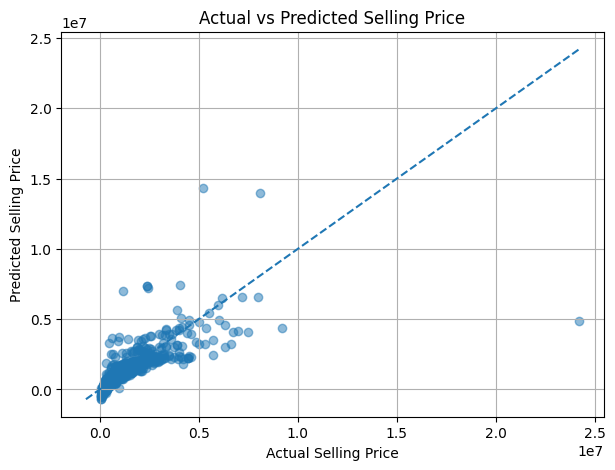

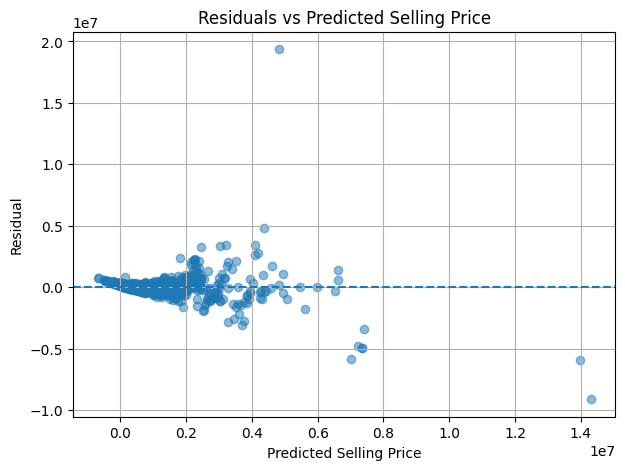

10 Observations with the Largest Prediction Errors:


,Actual Selling Price,Predicted Selling Price,Residual,Absolute Error
0,24200000.0,4.835648e+06,1.936435e+07,1.936435e+07
1,5200000.0,1.430188e+07,-9.101876e+06,9.101876e+06
2,8100000.0,1.397969e+07,-5.879695e+06,5.879695e+06
3,1200000.0,7.008079e+06,-5.808079e+06,5.808079e+06
4,2400000.0,7.354284e+06,-4.954284e+06,4.954284e+06
5,2400000.0,7.352461e+06,-4.952461e+06,4.952461e+06
6,9200000.0,4.363370e+06,4.836630e+06,4.836630e+06
7,2450000.0,7.226323e+06,-4.776323e+06,4.776323e+06
8,6645000.0,3.219912e+06,3.425088e+06,3.425088e+06
9,7500000.0,4.096725e+06,3.403275e+06,3.403275e+06


In [98]:
# Task 19: Visualize and Analyze Model Performance

import matplotlib.pyplot as plt
import numpy as np

# Calculate residuals
residuals = ytest - y_pred


# 1. Actual vs Predicted Selling Price
plt.figure(figsize=(7, 5))

plt.scatter(
    ytest,
    y_pred,
    alpha=0.5
)

# Perfect prediction reference line
min_value = min(ytest.min(), y_pred.min())
max_value = max(ytest.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.grid(True)
plt.show()


# 2. Residual Plot
plt.figure(figsize=(7, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

# Zero-error reference line
plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Selling Price")
plt.grid(True)
plt.show()


# 3. Identify observations with large prediction errors

absolute_errors = np.abs(residuals)

large_error_indices = np.argsort(
    absolute_errors
)[-10:][::-1]

large_errors = pd.DataFrame({
    "Actual Selling Price": ytest[large_error_indices],
    "Predicted Selling Price": y_pred[large_error_indices],
    "Residual": residuals[large_error_indices],
    "Absolute Error": absolute_errors[large_error_indices]
})

print("10 Observations with the Largest Prediction Errors:")
display(large_errors)

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


Most Influential Features

Features with larger regression coefficients have more effect on the predicted selling price. In this model, features such as vehicle age, km driven, engine, max power, brand, and model can influence the car price.

Advantages
Simple and easy to understand.
Uses multiple features for prediction.
Coefficients show the effect of each feature.
Easy to implement using NumPy.
Limitations
Assumes a linear relationship.
Sensitive to outliers.
Multicollinearity can affect the model.
Some factors like car condition and service history may not be included.

### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.